
# Zero-Shot Tasks with BLIP2
# ==========================================================

# 🎓 Learning Objectives

By the end of this notebook, you will learn how to use **BLIP2** for:  
- **Image Captioning**  
- **Visual Question Answering (VQA)**  
- **Zero-Shot Classification**  

---

## 📖 Background

- **BLIP2** is a multimodal large language model that links vision and language for flexible image understanding.  
- Unlike traditional CV models, BLIP2 handles diverse tasks through natural language prompts.  
- **Zero-Shot Classification**: categorize images into unseen classes without explicit training.  

---

## 🍽️ Dataset: Food101

- **101 food categories**  
- **~101k images** with labels  
- Fine-grained, visually diverse dataset  

---

## 🔧 Approach

1. Load **Food101** dataset (Hugging Face)  
2. Initialize **BLIP2**  
3. Prompt for **captioning, VQA, and zero-shot classification**

### BLIP2

BLIP-2 is a multimodal model that connects vision (images) and language (text).
It acts as a bridge between a pretrained vision model (like a ViT or CLIP encoder) and a large language model (LLM, like OPT, Flan-T5, or LLaMA).

BLIP-2 has three main components:
1. **Vision Encoder**: This part takes an input image and extracts meaningful features. Instead of raw pixels, the encoder outputs numerical representations (embeddings) that capture the content of the image.
2. **Q-Former (Query Transformer)**: This is a small transformer model that sits between the vision encoder and the language model. It uses a set of learnable queries to interact with the image embeddings and then produces compact, language-friendly representations.
3. **Large Language Model (LLM)**: A pretrained language model (like Flan-T5 or LLaMA) takes the Q-Former’s output and generates text. This allows the system to perform tasks like answering questions about images or writing captions.

Training BLIP-2 is efficient because:
- The vision encoder and the LLM are frozen (not retrained).
- Only the Q-Former is trained to connect the two.

Why BLIP-2 Matters:
- It enables powerful multimodal tasks like visual question answering, image captioning, and multimodal reasoning.
- It leverages existing strong vision and language models instead of training from scratch.
- The Q-Former makes the system much more efficient and flexible.



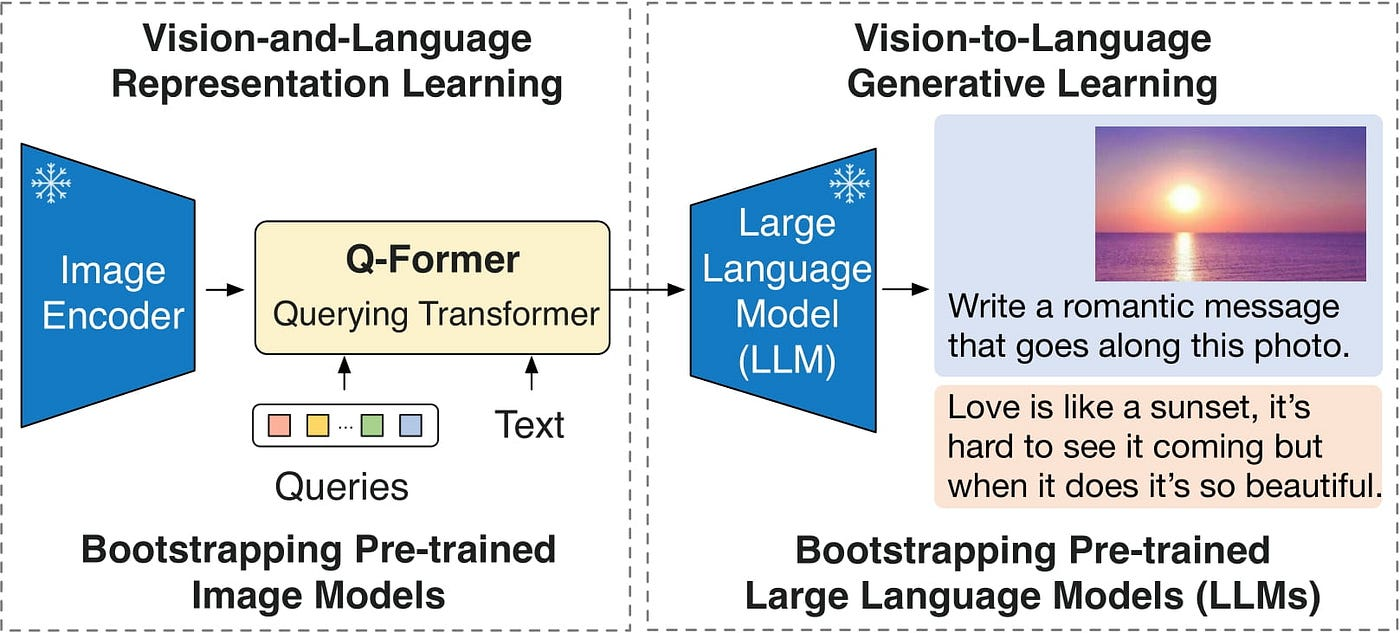

In [1]:
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore')

def install_requirements():
    """Install required packages for the notebook"""
    print("📦 Installing required packages...")
    print("This may take a few minutes on first run...")

    requirements = [
        "torch",
        "torchvision",
        "transformers>=4.37.0",
        "accelerate",
        "bitsandbytes",
        "datasets",  # Hugging Face datasets
        "Pillow",
        "requests",
        "numpy",
        "matplotlib",
        "seaborn",
        "tqdm",  # Progress bars
        "scikit-learn"  # Evaluation metrics
    ]

    for package in requirements:
        try:
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", package, "-q"
            ])
        except:
            print(f"⚠️ Failed to install {package}, continuing...")

    print("✅ Installation complete!")

# Run installation
install_requirements()

📦 Installing required packages...
This may take a few minutes on first run...


✅ Installation complete!


In [2]:
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

#### Load the Model from HuggingFace

In [3]:
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:42<00:00, 21.04s/it]


Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  (qf

### Load Image

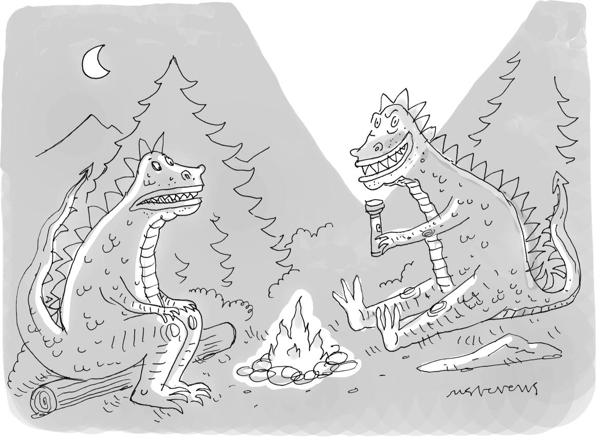

In [4]:
url = 'https://media.newyorker.com/cartoons/63dc6847be24a6a76d90eb99/master/w_1160,c_limit/230213_a26611_838.jpg'
image = Image.open(requests.get(url, stream=True).raw).convert('RGB')
display(image.resize((596, 437)))

### Image Captioning
To caption an image, we do not have to provide any text prompt to the model only the preprocessed input image. Without any text prompt, the model will start generating text from the BOS (beginning-of-sequence) token thus creating a caption.

In [5]:
inputs = processor(image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text)

two cartoon monsters sitting around a campfire


### Prompted image captioning
Extend image captioning by providing a text prompt

In [6]:
prompt = "they look like they are" 

inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text) # the model completes this prompt with next token prediction

they look like they are having a good time


### Visual question answering
For visual question answering the prompt has to follow a specific format: "Question: {} Answer:"

In [7]:
prompt = "Question: What is a dinosaur holding? Answer:"

inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=10)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text)

Question: What is a dinosaur holding? Answer: A torch


### Zero-shot Image Classification

In [10]:
class Food101Dataset(Dataset):
    def __init__(self, split='validation', transform=None, query_template=None):
        self.dataset = load_dataset("ethz/food101", split=split)
        self.transform = transform
        self.query_template = query_template


        self.classnames = [
            'apple pie', 'baby back ribs', 'baklava', 'beef carpaccio', 'beef tartare',
            'beet salad', 'beignets', 'bibimbap', 'bread pudding', 'breakfast burrito',
            'bruschetta', 'caesar salad', 'cannoli', 'caprese salad', 'carrot cake',
            'ceviche', 'cheese plate', 'cheesecake', 'chicken curry', 'chicken quesadilla',
            'chicken wings', 'chocolate cake', 'chocolate mousse', 'churros', 'clam chowder',
            'club sandwich', 'crab cakes', 'creme brulee', 'croque madame', 'cup cakes',
            'deviled eggs', 'donuts', 'dumplings', 'edamame', 'eggs benedict',
            'escargots', 'falafel', 'filet mignon', 'fish and chips', 'foie gras',
            'french fries', 'french onion soup', 'french toast', 'fried calamari',
            'fried rice', 'frozen yogurt', 'garlic bread', 'gnocchi', 'greek salad',
            'grilled cheese sandwich', 'grilled salmon', 'guacamole', 'gyoza', 'hamburger',
            'hot and sour soup', 'hot dog', 'huevos rancheros', 'hummus', 'ice cream',
            'lasagna', 'lobster bisque', 'lobster roll sandwich', 'macaroni and cheese',
            'macarons', 'miso soup', 'mussels', 'nachos', 'omelette', 'onion rings',
            'oysters', 'pad thai', 'paella', 'pancakes', 'panna cotta', 'peking duck',
            'pho', 'pizza', 'pork chop', 'poutine', 'prime rib', 'pulled pork sandwich',
            'ramen', 'ravioli', 'red velvet cake', 'risotto', 'samosa', 'sashimi',
            'scallops', 'seaweed salad', 'shrimp and grits', 'spaghetti bolognese',
            'spaghetti carbonara', 'spring rolls', 'steak', 'strawberry shortcake',
            'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna tartare', 'waffles'
        ]

        if self.query_template is None:
            self.query_template = (
                "Question: Which food is this?\n"
                f"Choose from the following options: {', '.join(self.classnames)}\n"
                "Answer:"
            )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample['image']
        if isinstance(image, str):
            image = Image.open(image)
        image = image.convert('RGB')

        label = sample['label']
        query = self.query_template

        if self.transform:
            processed_sample = self.transform(images=image, text=query, return_tensors="pt")
            processed_sample = {k: v.squeeze(0) for k, v in processed_sample.items()}
        else:
            processed_sample = {"image": image, "prompt": query}

        return {
            **processed_sample,
            "label": label,
            "sample_idx": idx
        }

    def show_sample_images(self, num_samples=4):
        """Display sample images from the dataset"""
        print(f"Sample images from the Food101 dataset:")

        # Randomly select samples
        indices = np.random.choice(len(self), num_samples, replace=False)

        n_rows = (num_samples + 1) // 2
        n_cols = 2
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
        axes = axes.flatten()

        for i, idx in enumerate(indices):
            sample = self.__getitem__(int(idx))
            classname = self.classnames[sample['label']]
            axes[i].imshow(sample['image'])
            axes[i].set_title(f"{classname}\n(Class {sample['label']})")
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

Sample images from the Food101 dataset:


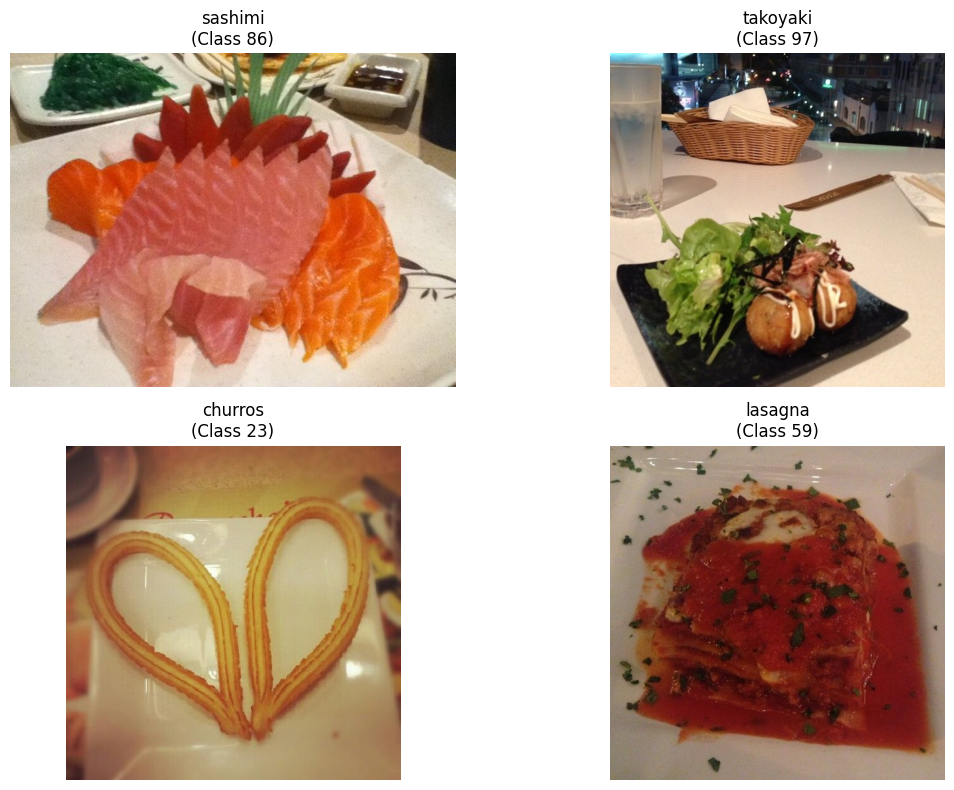

In [11]:
dataset = Food101Dataset(split='validation')
dataset.show_sample_images(4)

Ground Truth: ramen


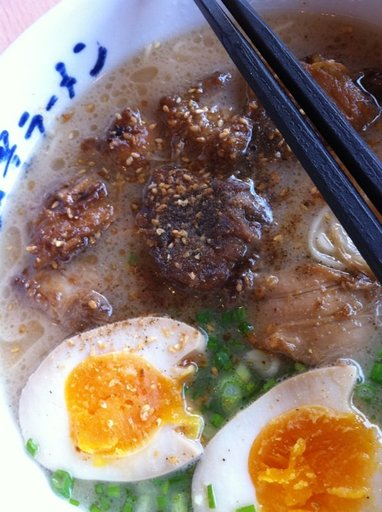

In [12]:
sample = dataset[544]
image, prompt = sample['image'], sample['prompt']
print("Ground Truth:", dataset.classnames[sample['label']])
display(dataset[544]['image'])

In [13]:
inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text)

Question: Which food is this?
Choose from the following options: apple pie, baby back ribs, baklava, beef carpaccio, beef tartare, beet salad, beignets, bibimbap, bread pudding, breakfast burrito, bruschetta, caesar salad, cannoli, caprese salad, carrot cake, ceviche, cheese plate, cheesecake, chicken curry, chicken quesadilla, chicken wings, chocolate cake, chocolate mousse, churros, clam chowder, club sandwich, crab cakes, creme brulee, croque madame, cup cakes, deviled eggs, donuts, dumplings, edamame, eggs benedict, escargots, falafel, filet mignon, fish and chips, foie gras, french fries, french onion soup, french toast, fried calamari, fried rice, frozen yogurt, garlic bread, gnocchi, greek salad, grilled cheese sandwich, grilled salmon, guacamole, gyoza, hamburger, hot and sour soup, hot dog, huevos rancheros, hummus, ice cream, lasagna, lobster bisque, lobster roll sandwich, macaroni and cheese, macarons, miso soup, mussels, nachos, omelette, onion rings, oysters, pad thai, pae